In [1]:
###
library(dplyr)
library(Matrix)
library(data.table)
library(Seurat)
library(ggplot2)
library(RColorBrewer)
cols = c(brewer.pal(9, "Set1"),brewer.pal(8,"Set2")[1:8],brewer.pal(12,"Paired")[1:12],brewer.pal(8,"Dark2")[1:8],brewer.pal(8,"Accent"),brewer.pal(12, "Set3"),brewer.pal(9,"Pastel1"),brewer.pal(8,"Pastel2"))
celltype = c("L2 IT neurons", "L2/3 IT neurons", "L3 IT neurons", "L3-6 IT neurons", "L3/4 IT neurons", 
 "L4 IT neurons", "L4/5 IT neurons", "L5 ET neurons", "L5/6 CAR3 neurons", "L5/6 NP neurons", 
 "L6 CT neurons", "L6 IT neurons", "L6b neurons", "LAMP5 neurons", "PVALB Chandelier neurons", 
 "PVALB neurons", "RELN neurons", "SST CHODL neurons", "SST neurons", "VIP neurons", 
 "Astrocytes", "Microglia", "Oligodendrocyte precursor cells", "Oligodendrocytes", 
 "Vascular cells")

best_color = c("#EA5514", "#D23918", "#FFB400", "#99F880", "#da32e9", 
 "#00e2ff", "#832aff", "#008396", "#01fac9", "#940202", 
 "#01fa65", "#00adff", "#058d32", "#c10265", "#bea013", 
 "#bcbe13", "#FF0000", "#ebb076", "#fa5a03", "#e06565", 
 "#7E9853", "#6565bc", "#b5a48d", "#90734e", "#88C6CE")

names(best_color) = celltype


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘Matrix’ was built under R version 4.2.3”

Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


The legacy packages maptools, rgdal, and rgeos, underpinning this package
will retire shortly. Please refer to R-spatial evolution reports on
https://r-spatial.org/r/2023/05/15/evolution4.html for details.
This package is now running under evolution status 0 

Attaching SeuratObject



In [2]:
Chip =  c("GroupI-1","GroupI-2","GroupI-3","GroupI-4",'GroupI-5',
          "GroupⅡ-1","GroupⅡ-2",'GroupⅡ-3',"GroupⅡ-4",
          "GroupⅢ-1","GroupⅢ-2","GroupⅢ-3","GroupⅢ-4","GroupⅢ-5")  ##For example

In [40]:
merge_long = c()

for(chip in Chip){
data_transformed = read.csv(paste0('/data/ACC/average/',chip,'_ACC_all_methods_average_values_per_method.csv'))
# Invert the KL, JS, and MSE columns (negatively correlated metrics).
data_transformed$KL <- max(data$KL) - data$KL
data_transformed$JS <- max(data$JS) - data$JS
data_transformed$MSE <- max(data$MSE) - data$MSE

# Sort each column and normalize it (between 0 and 1).
data_normalized <- data.frame(lapply(data_transformed[,-1], function(x) {
  rank_x <- rank(x)  # Sort each column.
  return((rank_x - min(rank_x)) / (max(rank_x) - min(rank_x)))  # Normalize to 0–1
}))

# Add row names (method column) to the data frame.
data_normalized$Method <- data$Method

# Convert data from wide to long format.
library(tidyr)
data_long <- pivot_longer(data_normalized, 
                          cols = -Method, 
                          names_to = "Metric", 
                          values_to = "Rank")
data_long$Chip =  chip  
merge_long  = rbind(data_long,merge_long)

}

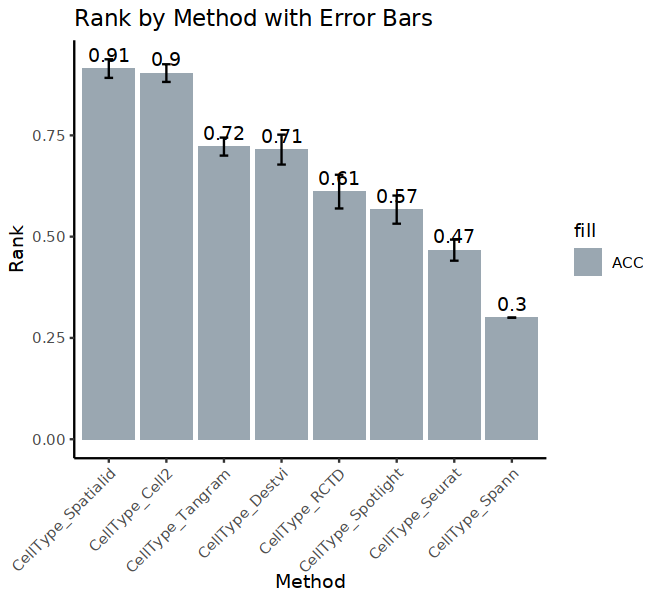

In [67]:
library(ggplot2)
library(dplyr)
DATA = merge_long[merge_long$Metric%in%c('MSE','JS','SSIM'),]

# Calculate the average Rank for the same Method.
data_avg <- DATA %>%
  group_by(Method,Chip) %>%
  summarise(AvgRank = mean(Rank), .groups = "drop")

data_error <- data_avg %>%
  group_by(Method) %>%
  summarise(
    MeanRank = mean(AvgRank),      # Calculate the mean of the ranks.
    SDRank = sd(AvgRank) / sqrt(n())  # Calculating the Standard Error of the Rank
  )

# Sort the data by MeanRank.
data_error_sorted <- data_error %>%
  arrange(desc(MeanRank))
# Plot a bar chart and add error bars.
options(repr.plot.width=5.5, repr.plot.height=5) 

ggplot(data_error_sorted, aes(x = reorder(Method, -MeanRank), y = MeanRank,fill = 'ACC')) +
  geom_bar(stat = "identity", position = "dodge", show.legend = TRUE) +
  scale_fill_manual(values = "#9aa7b1") + 
  geom_text(aes(label = round(MeanRank, 2)), position = position_dodge(width = 0.8), vjust = -0.5) +
  geom_errorbar(aes(ymin = MeanRank - SDRank, ymax = MeanRank + SDRank), 
                position = position_dodge(width = 0.8), width = 0.15) + 
  labs(x = "Method", y = "Rank", title = "Rank by Method with Error Bars") + 
  theme_classic() + 
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) 
ggsave(paste0('/data/ACC_plot.pdf'),width = 6,height = 5)